We formalise the template attack from the "hardware runner" file into a template attack more commonly decribe in the literature.

In [1]:
import chipwhisperer as cw
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA
from scipy import stats
import sys
import seaborn as sns
import scipy.signal
sys.path.append("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/")
from privacy_amplification.FFT.FFT import *
import TA_tools
import importlib
importlib.reload(TA_tools)
import scienceplots


SCOPETYPE = 'OPENADC'
PLATFORM = 'CW308_SAM4S'
SS_VER = 'SS_VER_2_1'

In [2]:
%run "/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/adversary/TA_segmented_initialise.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7370129.87012987         
scope.clock.adc_freq                     changed from 0                         to 29480519.48051948        
scope.clock.extclk_monitor_enabled       changed from True                      to False                    
scope.clock.extclk_tolerance             changed from 1144409.1796875           to 13096723.705530167       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx         

In [3]:
tools = TA_tools.Tools(scope,target)

In [4]:
x0 = "00000000\n"  #00
x1 = "00001000\n"  #01
x2 = "10000000\n"  #10
x3 = "10001000\n"  #11

dummy = "11111111\n"
warmup = tools.get_trace(dummy)

Trig count: 6547


In [5]:
scope.adc.errors

False

In [6]:
t1 = tools.get_trace(x0)
cw.plot(t1)

Trig count: 6523


:Curve   [x]   (y)

In [18]:
def gen_samples_seg(input, dummy, num):
    
    samples = []
    for i in range(num):
        s = tools.get_trace(input)
        samples.append(s[0])
        if i % 500 == 0:
            target.flush()
            reset_target(scope)
            for i in range(5):
                warmup = tools.get_trace(dummy)
    return np.asarray(samples)

def gen_samples_mono(input, dummy, num):
    
    samples = []
    for i in range(num):
        s = tools.get_trace(input)
        samples.append(s)
        if i % 500 == 0:
            target.flush()
            reset_target(scope)
            for i in range(5):
                warmup = tools.get_trace(dummy)
    return np.asarray(samples)

In [10]:
L = 50
classes = 4
sample_points = 7000

In [21]:

samples = np.zeros([classes*L, sample_points])
samples[:1*L] = gen_samples_mono(x0, dummy, L)
samples[1*L:2*L] = gen_samples_mono(x1, dummy, L)
samples[2*L:3*L] = gen_samples_mono(x2, dummy, L)
samples[3*L:] = gen_samples_mono(x3, dummy, L)




#sx0 = gen_samples(x0, dummy, num)
#sx1 = gen_samples(x1, dummy, num)
#sx2 = gen_samples(x2, dummy, num)
#sx3 = gen_samples(x3, dummy, num)


Trig count: 6523
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523
Trig count: 6523


Trig count: 6519
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519
Trig count: 6519


Trig count: 6516
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516
Trig count: 6516


Trig count: 6529
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529
Trig count: 6529


In [22]:
def artifically_add_gaussian_noise(samples_in, sigma):
    num_samples = samples_in.shape[0]
    sample_size = samples_in.shape[1]

    samples_out = np.zeros(samples_in.shape)

    for n in range(num_samples):
        gx = np.random.normal(0,sigma,sample_size)
        samples_out[n] = samples_in[n] + gx
    
    return samples_out

In [23]:
noisey_samples = artifically_add_gaussian_noise(samples, 0)

In [ ]:
pca = PCA(n_components=3)
pca.fit(noisey_samples)
noisey_samples = pca.transform(noisey_samples)


In [24]:
sx0_mean = tools.calculate_mean_sample(noisey_samples[:1*L])
sx1_mean = tools.calculate_mean_sample(noisey_samples[1*L:2*L])
sx2_mean = tools.calculate_mean_sample(noisey_samples[2*L:3*L])
sx3_mean = tools.calculate_mean_sample(noisey_samples[3*L:])

means = np.asarray([sx0_mean, sx1_mean, sx2_mean, sx3_mean])

#np.save("means_multivariate_gaussian_mcu.npy", means)

In [ ]:
means = np.load("means_multivariate_gaussian_mcu.npy")
sx0_mean = means[0]
sx1_mean = means[1]
sx2_mean = means[2]
sx3_mean = means[3]

/tmp/ipykernel_72760/2944701862.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


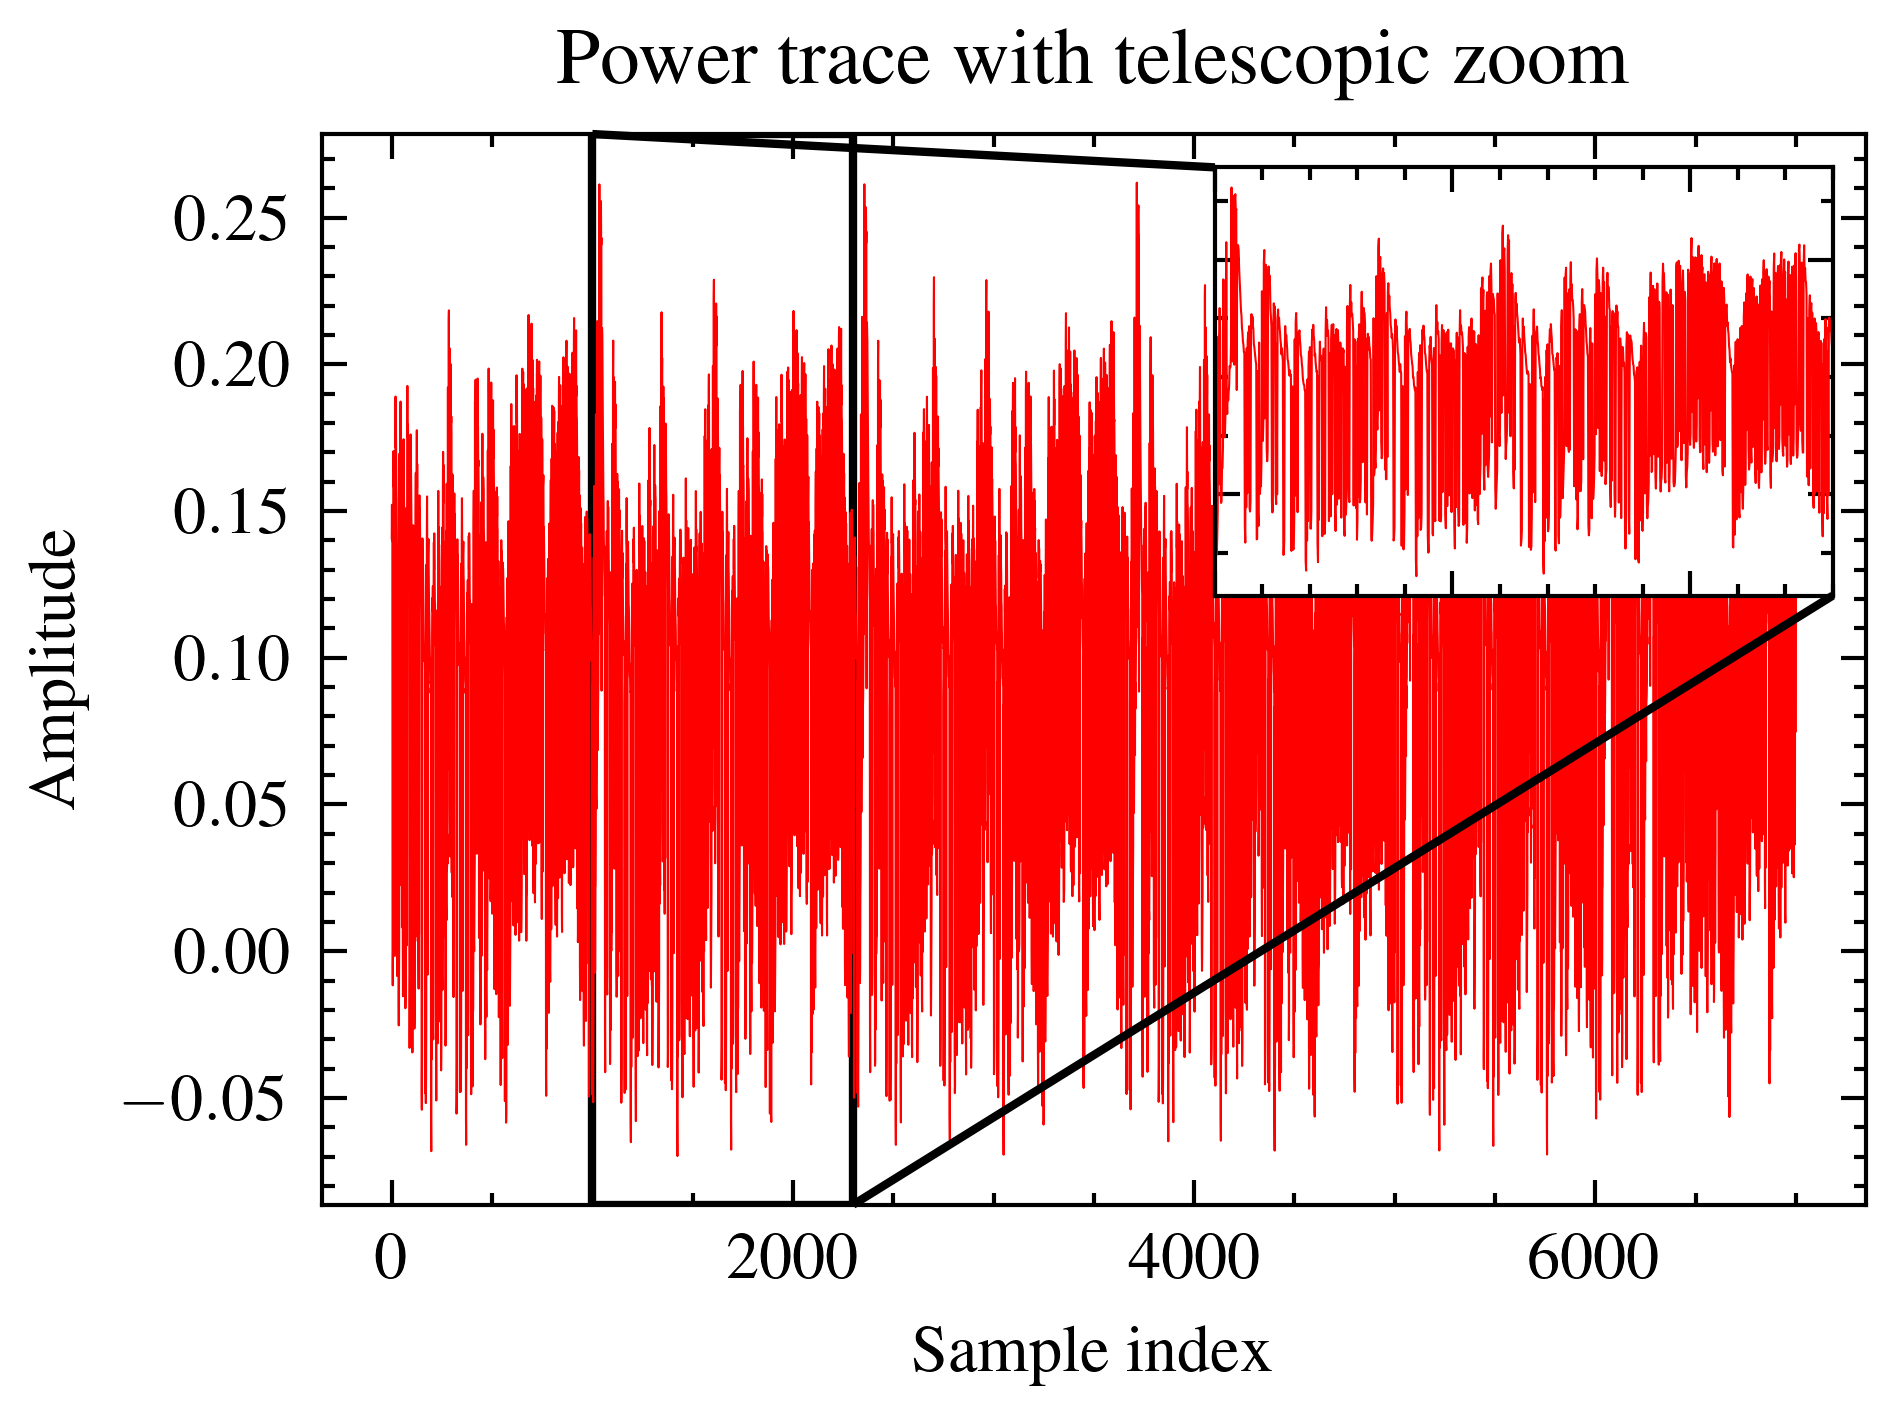

In [54]:
lw = 0.25
col1 = 'r'


fig, ax = plt.subplots()

# --- Full trace ---
ax.plot(sx0_mean, label="Power trace", color=col1, linewidth=lw)
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude")
ax.set_title("Power trace with telescopic zoom")

# --- Add inset zoom ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# create inset axis
axins = inset_axes(ax, width="40%", height="40%", loc="upper right")

# plot zoomed region in inset
x1, x2 = 1000, 2300   # x-range of zoom
axins.plot(sx0_mean,color=col1, linewidth=lw)
axins.set_xlim(x1, x2)
#axins.set_ylim(sx0_mean[(x >= x1) & (x <= x2)].min(),
              # sx0_mean[(x >= x1) & (x <= x2)].max())

# remove tick labels for clarity
axins.set_xticklabels([])
axins.set_yticklabels([])

# draw lines linking zoom to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0")

plt.tight_layout()
plt.show()


In [25]:
cw.plot(sx0_mean) * cw.plot(sx1_mean) * cw.plot(sx2_mean) * cw.plot(sx3_mean)

:Overlay
   .Curve.I   :Curve   [x]   (y)
   .Curve.II  :Curve   [x]   (y)
   .Curve.III :Curve   [x]   (y)
   .Curve.IV  :Curve   [x]   (y)

In [ ]:
s=5070
e=5220
lw = 0.6
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science','ieee'])
#plt.style.use('science')

#plt.style.use('seaborn-v0_8-colorblind')
#plt.style.use('tableau-colorblind10')
#plt.style.use('seaborn-v0_8-paper')

plt.plot(sx0_mean, linewidth=lw, label="00")
plt.plot(sx1_mean, linewidth=lw, label="01")
plt.plot(sx2_mean, linewidth=lw, label="10")
plt.plot(sx3_mean, linewidth=lw, label="11")
plt.xlabel("Sample Point")#,fontsize=12)
plt.ylabel("Voltage, mV")#,fontsize=12)
plt.legend(loc='upper center', ncol=4)#,fontsize=12)
plt.xlim(s,e)  
plt.tight_layout()
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/power_difference_bf1_zoom_2.png",dpi=500)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use('science')

plt.figure(figsize=(4,2))
x = np.arange(0,5,0.01)
y = np.sin(x)
plt.plot(x,y)
plt.show()

In [ ]:
def std_dev_calc(mu, x_list, N):
    sum = 0
    for i in range(N):
        sum = sum + (x_list[i] - mu)**2
    return np.sqrt((1/N)*sum)

In [ ]:
std_dev_list = []
for s in range(sample_points):
    std_dev_list.append(std_dev_calc(sx0_mean[s],noisey_samples[0:50,s],50))

In [ ]:

std_dev_list_cw312 = np.loadtxt("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/std_dev_list_cw312.csv", delimiter=",")
std_dev_list_cw305 = np.loadtxt("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/std_dev_list_cw305.csv", delimiter=",")

plt.plot(std_dev_list_cw305,linewidth=1.5, label="Artix-7")

plt.plot(std_dev_list_cw312[0:5000],linewidth=1.5, label="ARM Cortex-M4")

plt.xlabel("Sample Point",fontsize=12)
plt.ylabel("Standard Deviation, $\sigma$",fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/noise_distribution.png",dpi=500)
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

# CW312
ax1.plot(std_dev_list_cw312, linewidth=1.5, color='tab:blue')
ax1.set_title("CW312", fontsize=12)
ax1.set_xlabel("Sample Point", fontsize=12)
ax1.set_ylabel("Standard Deviation, $\sigma$", fontsize=12)

# CW305
ax2.plot(std_dev_list_cw305, linewidth=1.5, color='tab:orange')
ax2.set_title("CW305", fontsize=12)
ax2.set_xlabel("Sample Point", fontsize=12)

plt.tight_layout()
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/noise_distribution.png", dpi=500)
plt.show()

In [ ]:
fig, ax1 = plt.subplots()

# First line
x1 = range(len(std_dev_list_cw312))
ax1.plot(x1, std_dev_list_cw312, label='CW312', linewidth=1.5, color='tab:blue')
ax1.set_xlabel("CW312 Sample Point", fontsize=12)
ax1.set_ylabel("Standard Deviation, $\sigma$", fontsize=12)
ax1.tick_params(axis='x', labelcolor='tab:blue')

# Second x-axis
ax2 = ax1.twiny()
x2 = range(len(std_dev_list_cw305))
ax2.plot(x2, std_dev_list_cw305, label='CW305', linewidth=1.5, color='tab:orange')
ax2.set_xlabel("CW305 Sample Point", fontsize=12)
ax2.tick_params(axis='x', labelcolor='tab:orange')

plt.tight_layout()
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/noise_distribution.png", dpi=500)
plt.show()

In [ ]:
np.asarray(std_dev_list).tofile("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/std_dev_list_cw312.csv", sep=",")

In [ ]:
cov_mat = np.zeros([4,4])

for i in range(4):
    for j in range(4):
        pc = stats.pearsonr(means[i], means[j])
        cov_mat[i,j] = pc[0]

class_labels = ["00", "01", "10", "11"]
ax = sns.heatmap(cov_mat, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Sample 2',fontsize=12)
plt.ylabel('Sample 1',fontsize=12)
plt.title('Pearson Coefficient Matrix',fontsize=12)
plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/pearson_matrix",dpi=500)
plt.show()

TVLA Tests

In [26]:
from tqdm.autonotebook import trange

correct_key = np.random.randint(2,size=8)
correct_key_str = tools.array_to_bin_input(correct_key)
N = 100
group1 = []
group2 = []
for i in trange(N, desc="Capturing Traces"):
    traces_cor = np.asarray(gen_samples_mono(correct_key_str,dummy,1))
    rand_key = np.random.randint(2,size=8)
    rand_key_str = tools.array_to_bin_input(rand_key)
    trace_rand = np.asarray(gen_samples_mono(rand_key_str,dummy,1))
    group1.append(traces_cor)
    if(rand_key_str != correct_key_str):
        group2.append(trace_rand)
    else:
        group1.append(trace_rand)
group1 = np.asarray(group1)
group2 = np.asarray(group2)

print(len(group1))
print(len(group2))

/tmp/ipykernel_72760/784544679.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


Capturing Traces:   0%|          | 0/100 [00:00<?, ?it/s]

Trig count: 6541
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6515
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6541
Trig count: 6547
Trig count: 6547
Trig count: 6547


...

Trig count: 6547
Trig count: 6547
Trig count: 6528
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6541
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6525
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6541
Trig count: 6547
Trig count: 6547
Trig count: 6547


Trig count: 6547
Trig count: 6547
Trig count: 6508
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
Trig count: 6547
101
99


In [32]:
group1 = group1[0:100].reshape([100,sample_points])
group2 = group2.reshape([99,sample_points])

In [ ]:
np.save("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/mcu_tvla_group1.npy", group1)
np.save("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/mcu_tvla_group2.npy", group2)

In [ ]:
group1 = np.load("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/mcu_tvla_group1.npy")
group2 = np.load("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/mcu_tvla_group2.npy")

In [33]:
mean1 = np.mean(group1, axis=0)
mean2 = np.mean(group2, axis=0)

In [34]:
cw.plot(mean2) * cw.plot(mean1)

:Overlay
   .Curve.I  :Curve   [x]   (y)
   .Curve.II :Curve   [x]   (y)

In [35]:
cw.plot(mean1 - mean2)

:Curve   [x]   (y)

In [36]:
from scipy.stats import ttest_ind
t_val = ttest_ind(group1, group2, axis=0, equal_var=False)[0]
cw.plot(t_val)

:Curve   [x]   (y)

In [37]:
group1_fpga = np.loadtxt("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/fpga_tvla_group1.csv", delimiter=",")
group2_fpga = np.loadtxt("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/fpga_tvla_group2.csv", delimiter=",")

In [38]:
import holoviews as hv
N = len(group1)
t_val = [ttest_ind(group1[:N//2], group2[:N//2], axis=0, equal_var=False)[0], 
         ttest_ind(group1[N//2:], group2[N//2:], axis=0, equal_var=False)[0]]

cv = cw.plot(t_val[0]) * cw.plot(t_val[1])
cv *= cw.plot([4.5]*len(group1[0]))
cv *= cw.plot([-4.5]*len(group1[0]))
cv

:Overlay
   .Curve.I   :Curve   [x]   (y)
   .Curve.II  :Curve   [x]   (y)
   .Curve.III :Curve   [x]   (y)
   .Curve.IV  :Curve   [x]   (y)

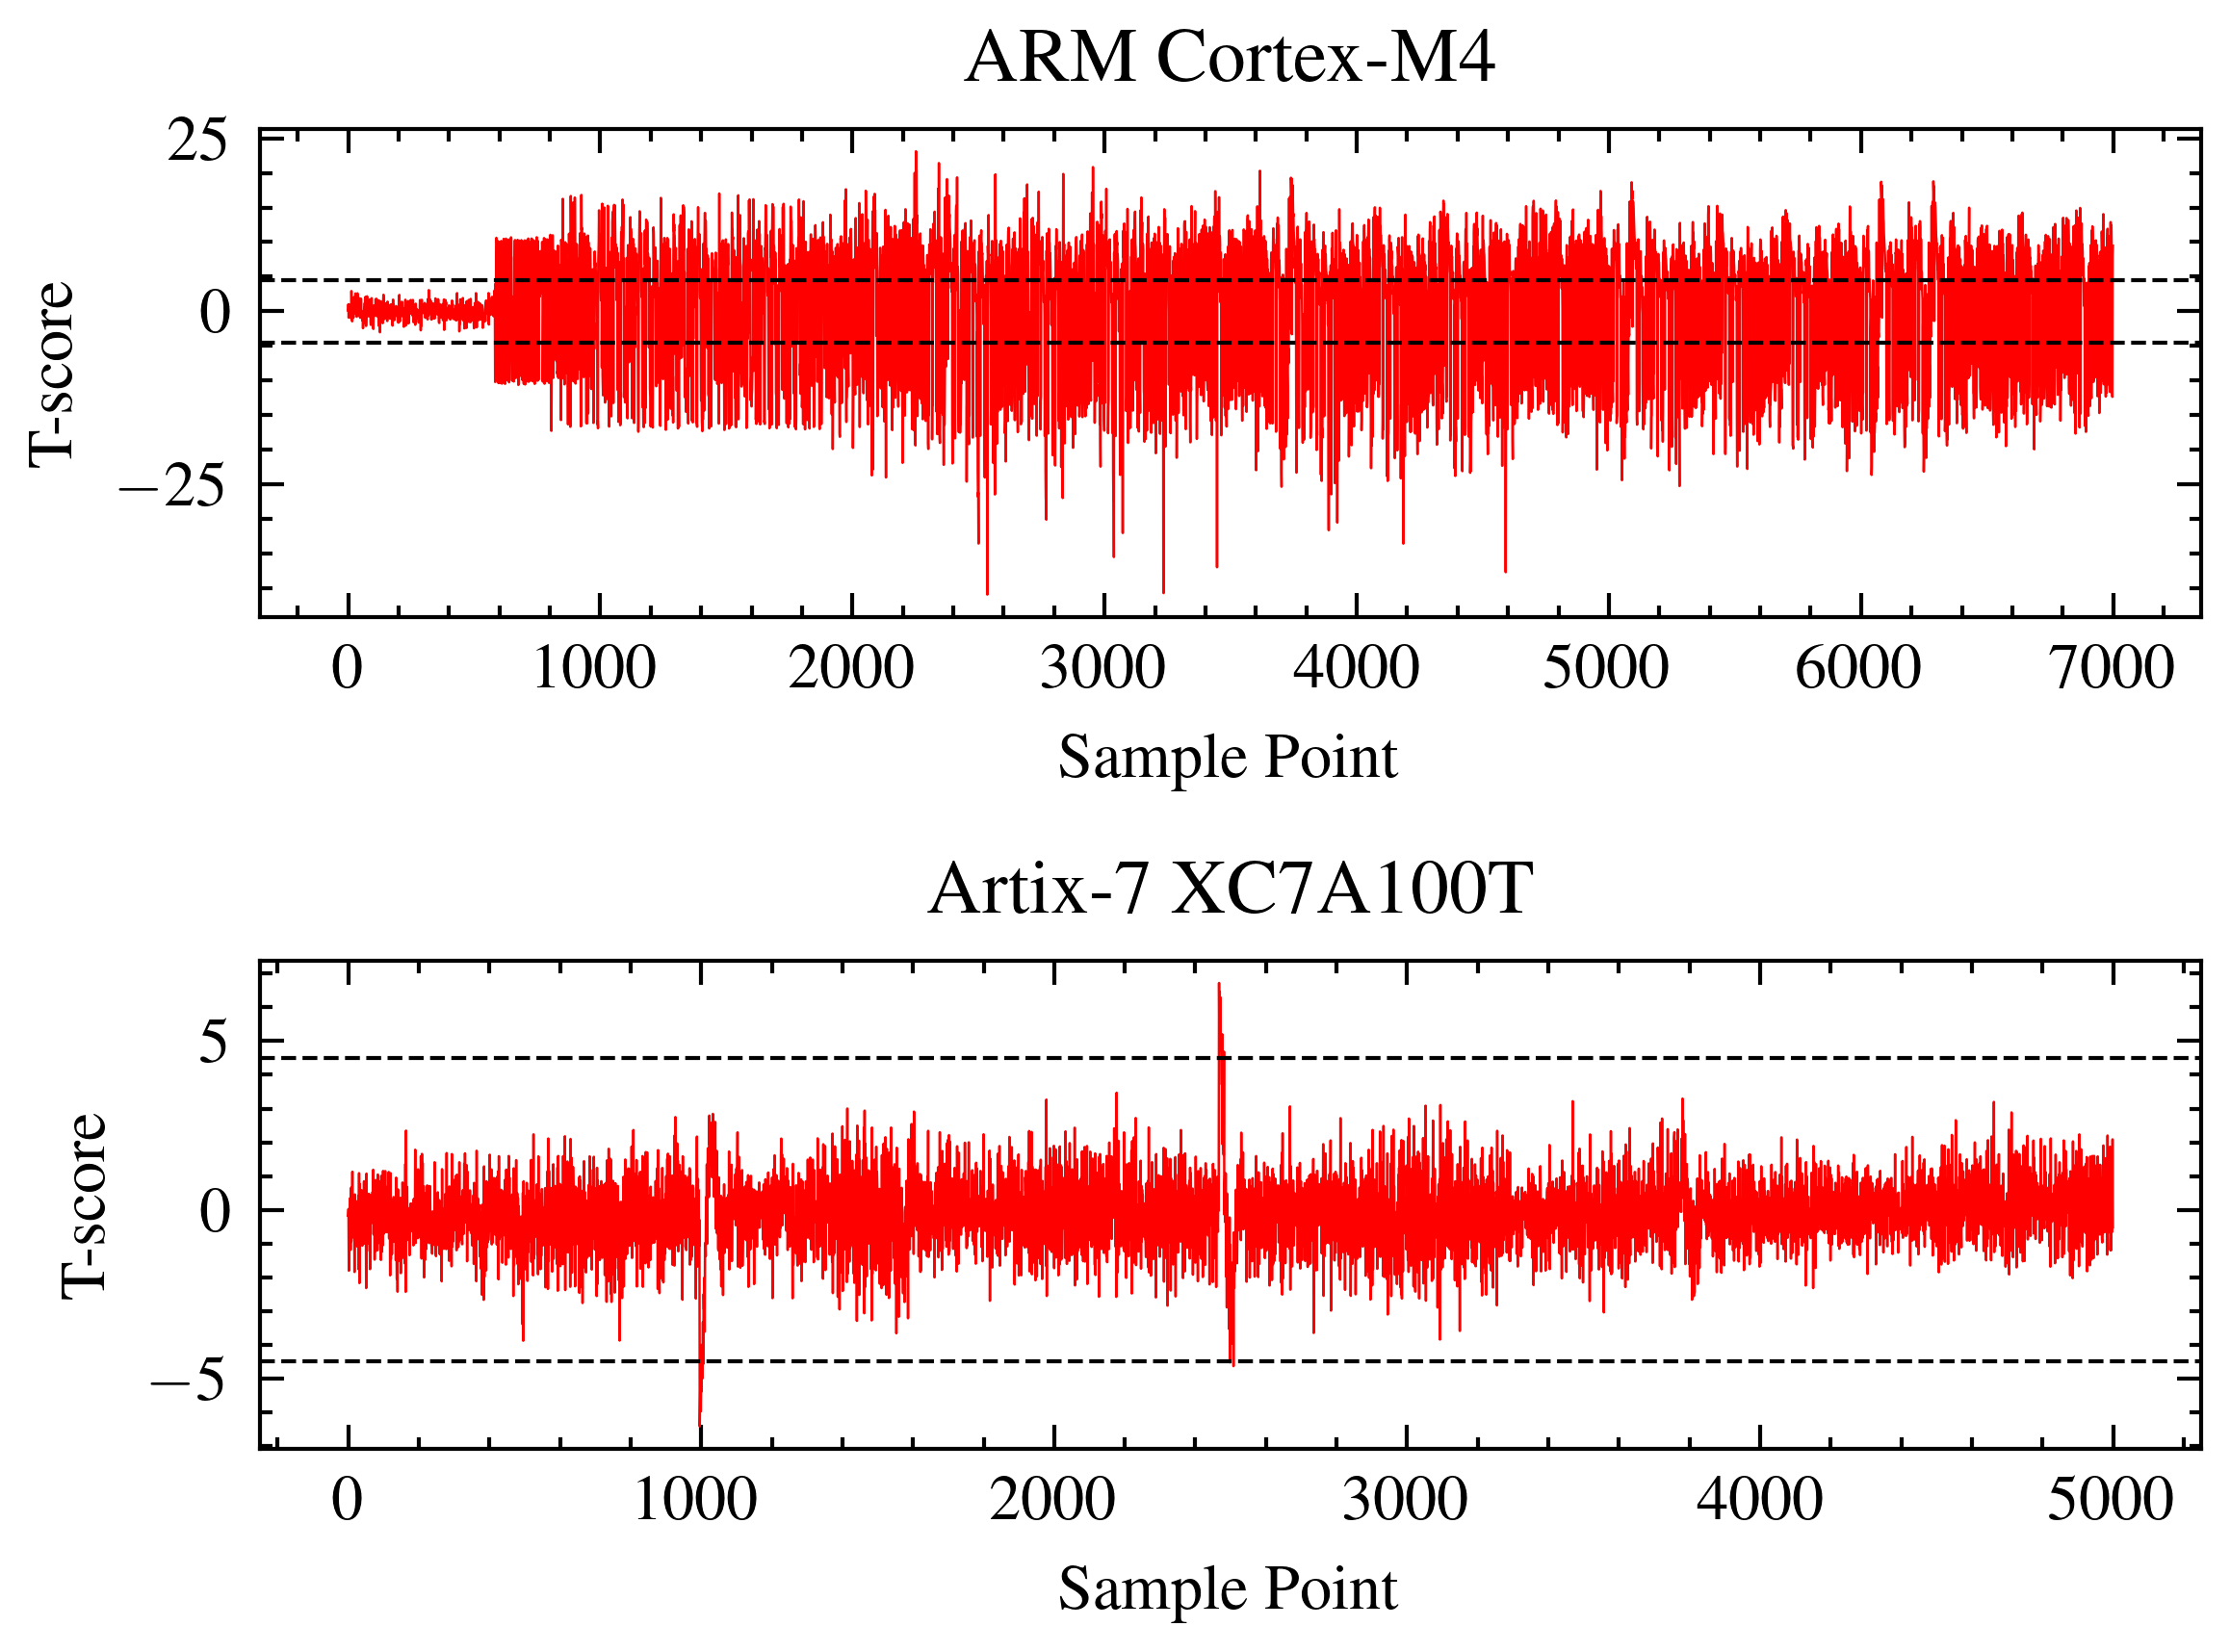

In [39]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science','ieee'])
#plt.style.use('seaborn-v0_8-darkgrid')

N = len(group1)
#t_val_mcu = [ttest_ind(group1[:N//2], group2[:N//2], axis=0, equal_var=False)[0], 
         #ttest_ind(group1[N//2:], group2[N//2:], axis=0, equal_var=False)[0]]

N_fpga = len(group1_fpga)
#t_val_fpga = [ttest_ind(group1_fpga[:N_fpga//2], group2_fpga[:N_fpga//2], axis=0, equal_var=False)[0], 
         #ttest_ind(group1_fpga[N_fpga//2:], group2_fpga[N_fpga//2:], axis=0, equal_var=False)[0]]

t_val_mcu = ttest_ind(group1, group2, axis=0, equal_var=False)[0]
         


t_val_fpga = ttest_ind(group1_fpga, group2_fpga, axis=0, equal_var=False)[0]

lw=0.3
lw2 = 0.5
col1='r'
col2='k'
lst = "--"

fig, axs = plt.subplots(2, figsize=(4,3))
axs[0].plot(t_val_mcu, linewidth=lw,color=col1)
#axs[0].plot(t_val_mcu[0])
axs[0].axhline(y=4.5, color=col2, linestyle=lst, linewidth=lw2)
axs[0].axhline(y=-4.5, color=col2, linestyle=lst, linewidth=lw2)
axs[0].set_xlabel("Sample Point")#,fontsize=12)
axs[0].set_ylabel("T-score")#,fontsize=12)
axs[0].set_title("ARM Cortex-M4")#,fontsize=12)


axs[1].plot(t_val_fpga, linewidth=lw,color=col1)
#axs[1].plot(t_val_fpga[1])
axs[1].axhline(y=4.5, color=col2, linestyle=lst, linewidth=lw2)
axs[1].axhline(y=-4.5, color=col2, linestyle=lst, linewidth=lw2)
axs[1].set_xlabel("Sample Point")#,fontsize=12)
axs[1].set_ylabel("T-score")#,fontsize=12)
axs[1].set_title("Artix-7 XC7A100T")#,fontsize=12)



plt.tight_layout()



plt.savefig("/home/40265864@ecit.qub.ac.uk/Toeplitz_attack/results/TVLA_comparisson.png",dpi=500)





In [ ]:
tools.plot_overlay(means)

In [ ]:
s0s1 = np.abs(sx0_mean - sx1_mean)
s0s2 = np.abs(sx0_mean - sx2_mean)
s0s3 = np.abs(sx0_mean - sx3_mean)

s1s2 = np.abs(sx1_mean - sx2_mean)
s1s3 = np.abs(sx1_mean - sx3_mean)

s2s3 = np.abs(sx2_mean - sx3_mean)


tools.plot_overlay([s0s1, s0s2, s0s3, s1s2, s1s3, s2s3])

In [ ]:
diff_sum = s0s1 + s0s2 + s0s3 + s1s2 + s1s3 + s2s3
tools.plot_overlay([diff_sum])

Heuristically Chosen points

In [ ]:
points = np.asarray([796, 1040, 1352, 1600, 1784, 2036, 2260, 2460, 2724, 2936])
points = np.arange(0,2999,50)
points = np.array([0,1,2])

In [ ]:
dets = []
invs = []
for i in range(classes):
    compressed_cov = tools.compute_noise_cov_mat(tools.compress_samples(noisey_samples[i*L:(i+1)*L], points), tools.compress_samples(np.reshape(means[i],[1,3]), points))
    det_cov = np.linalg.det(compressed_cov)
    inv_cov = np.linalg.inv(compressed_cov)
    dets.append(det_cov)
    invs.append(inv_cov)
dets = np.asarray(dets)
invs = np.asarray(invs)

In [ ]:
Confusion_matrix, confidence_matrix = tools.class_accuracy_exp(noisey_samples, points, means, dets, invs, L)
class_labels = ["00", "01", "10", "11"]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
ax = sns.heatmap(Confusion_matrix, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels, fmt=".0f")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.subplot(1,2,2)
ax = sns.heatmap(confidence_matrix, annot=True, cmap="PuBuGn",
                 xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confidence Matrix')
plt.tight_layout()
plt.show()

Timing Experiment

In [ ]:
N_list = [8,16,32,64,128,256,512,1024,2048]